## Rod Control Example

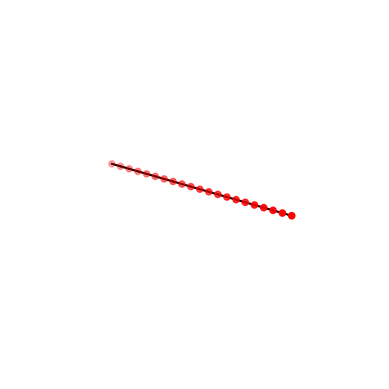

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=0.001,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=2e6,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dynamic_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('rft', ct=0.01, cn=0.1)
# env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=0.1)

geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n21.txt')

robot = dismech.SoftRobot(geom, material, geo, dynamic_2d_sim, env)

In [2]:
stepper = dismech.ImplicitEulerTimeStepper(robot)

## Reference configuration from npz

In [3]:
# read reference configuration from npz file
ref_data = np.load('snake_kappa_ref.npz')
ref_kappa_traj=ref_data['kappa_traj'] 
ref_times = ref_data['ref_times']

print("reference trajectory of kappa:", ref_kappa_traj)
print("reference times:", ref_times)

print("shape of reference kappa traj:", ref_kappa_traj.shape)


reference trajectory of kappa: [[[0.         0.19452384]
  [0.         0.18104541]
  [0.         0.15048179]
  ...
  [0.         0.14114662]
  [0.         0.17610849]
  [0.         0.19560265]]

 [[0.         0.20341949]
  [0.         0.20923508]
  [0.         0.19198041]
  ...
  [0.         0.1668206 ]
  [0.         0.19607577]
  [0.         0.20471539]]

 [[0.         0.19908212]
  [0.         0.20570049]
  [0.         0.18941673]
  ...
  [0.         0.14536717]
  [0.         0.18227941]
  [0.         0.1997574 ]]

 ...

 [[0.         0.19826681]
  [0.         0.17739677]
  [0.         0.13498605]
  ...
  [0.         0.168596  ]
  [0.         0.19531571]
  [0.         0.19852109]]

 [[0.         0.19944727]
  [0.         0.1827726 ]
  [0.         0.14389707]
  ...
  [0.         0.16140621]
  [0.         0.19212293]
  [0.         0.19969671]]

 [[0.         0.19984061]
  [0.         0.18742707]
  [0.         0.15223997]
  ...
  [0.         0.15357875]
  [0.         0.18817152]
  [0.  

In [4]:
def upsample_kappa(ref_times, ref_values, dt_fine):
    """Linear time upsampling to a uniform fine grid."""
    t0, t1 = ref_times[0], ref_times[-1]
    Nfine = int(np.floor((t1 - t0)/dt_fine)) + 1
    tfine = t0 + np.arange(Nfine) * dt_fine      # (Nfine,)
    T, Nb, D = ref_values.shape
    out = np.empty((Nfine, Nb, D), dtype=float)

    # vectorized over bends by stacking np.interp results
    for d in range(D):  # d = 0,1 components
        # build (Nb, Nfine) then transpose to (Nfine, Nb)
        comp = np.vstack([
            np.interp(tfine, ref_times, ref_values[:, i, d])
            for i in range(Nb)
        ]).T
        out[:, :, d] = comp
    return tfine, out

tfine, ref_fine = upsample_kappa(ref_times, ref_kappa_traj, dt_fine=robot.sim_params.dt)  # (Nfine, Nb, 2)


### Time Stepping
PID Control

In [5]:
from dismech.controllers.curvaturePITracker import CurvaturePITracker

# Y=1e6
Kp_kappa = 0.5
Ki_kappa = 0.5
Kd_kappa = 0.0

nat0 = robot.bend_springs.inc_strain.copy() 
tracker = CurvaturePITracker(
    nat0=nat0,
    # choose ONE of the two inputs below:
    # ref_func=ref_func, 
    ref_times=tfine, ref_values=ref_fine,   # (T,Nb,2)
    Kp=Kp_kappa, Ki=Ki_kappa, Kd=Kd_kappa, beta=1,
    du_rate_per_step=0.2, smooth_alpha=0.0, ref_smooth_alpha=0.02,
    kappa_mag_max=np.inf, antiwindup_bc=0.9
)

dt = dynamic_2d_sim.dt
bend_energy = None
pos_errors = []
bend_strain_errors = []
sat_flags = []

# Make a before_step callback that calls the controller each step
be = stepper.elastic_energies['bend']
dt = robot.sim_params.dt  # your dt

def actuate_track(robot, t):
    kappa_meas = be.get_strain(robot.state)                       # (Nb,2)
    nat = robot.bend_springs.inc_strain                           # (Nb,2), updated in-place
    nat_before = nat.copy()
    tracker.update(t, kappa_meas, nat, dt)                        # writes into nat
    sat_flags.append(np.linalg.norm(nat - nat_before) >= tracker.du_rate*0.99)  # rate sat proxy

    # error vs. the (unfiltered) reference at time t
    kappa_ref = tracker._get_ref(t)                  # (Nb,2)
    err = be.get_strain(robot.state) - (tracker.ref_filt if tracker.ref_filt is not None else tracker._get_ref(t))
    rmse = np.sqrt(np.mean(err**2))
    bend_strain_errors.append(rmse)

    # # (optional) per-node RMS magnitude for diagnostics
    # per_node_mag = np.linalg.norm(err, axis=1)       # (Nb,)
    # per_node_rmse.append(np.sqrt(np.mean(per_node_mag**2)))

    return robot


In [6]:

stepper.before_step = actuate_track
robots = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])


iter: 1, error: 0.026
iter: 2, error: 0.106
iter: 3, error: 0.000
current_time:  0.001
iter: 1, error: 0.028
iter: 2, error: 0.161
iter: 3, error: 0.000
current_time:  0.002
iter: 1, error: 0.029
iter: 2, error: 0.075
iter: 3, error: 0.000
current_time:  0.003
iter: 1, error: 0.030
iter: 2, error: 0.038
iter: 3, error: 0.000
current_time:  0.004
iter: 1, error: 0.030
iter: 2, error: 0.023
iter: 3, error: 0.000
current_time:  0.005
iter: 1, error: 0.030
iter: 2, error: 0.017
iter: 3, error: 0.000
current_time:  0.006
iter: 1, error: 0.028
iter: 2, error: 0.015
iter: 3, error: 0.000
current_time:  0.007
iter: 1, error: 0.024
iter: 2, error: 0.011
iter: 3, error: 0.000
current_time:  0.008
iter: 1, error: 0.019
iter: 2, error: 0.006
current_time:  0.009000000000000001
iter: 1, error: 0.014
iter: 2, error: 0.003
current_time:  0.01
iter: 1, error: 0.009
iter: 2, error: 0.002
current_time:  0.011
iter: 1, error: 0.006
iter: 2, error: 0.001
current_time:  0.012
iter: 1, error: 0.006
iter: 2,

In [7]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Rod PID', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

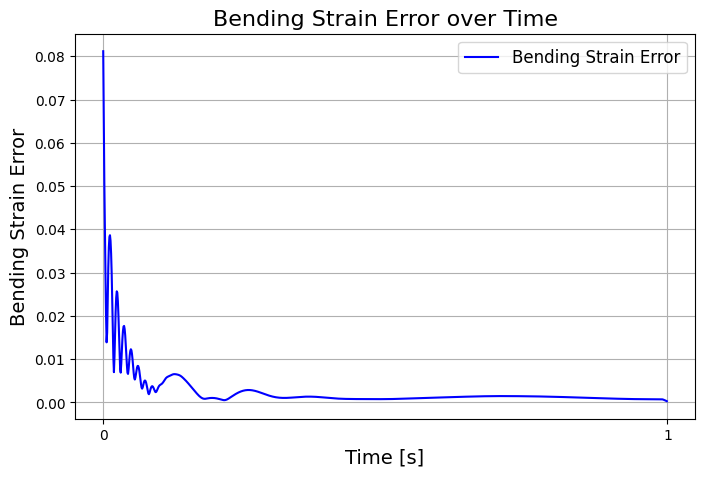

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# plot bending strain error over time
plt.figure(figsize=(8,5))
plt.plot(t, bend_strain_errors, label='Bending Strain Error', color='blue')
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Bending Strain Error', fontsize=14)
plt.title('Bending Strain Error over Time', fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.show()

In [9]:
sat_frac = np.mean(sat_flags)
print("Saturation fraction:", sat_frac)

Saturation fraction: 0.001


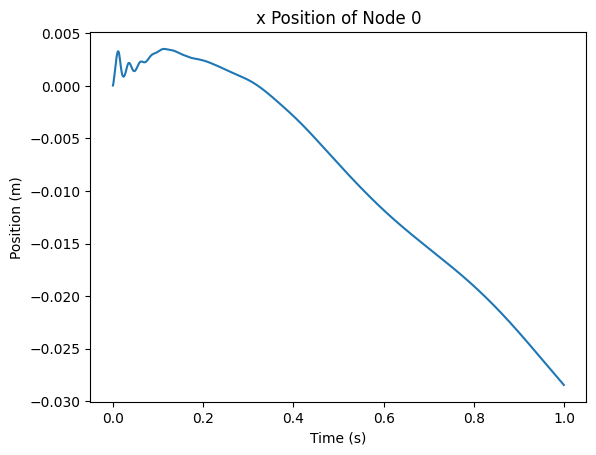

In [10]:
import matplotlib.pyplot as plt
plt.title("x Position of Node 0")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.plot(t, qs[:, 0])
plt.show()

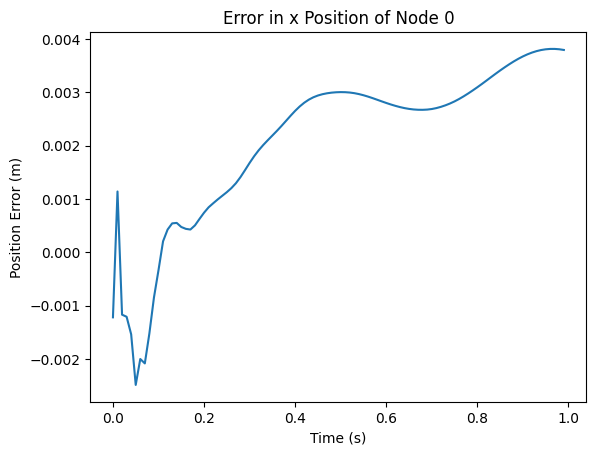

In [12]:
# error trajectory of node0 x coordinate
ref_data_node0 = np.loadtxt('snake_node0_trajectory.txt')
# error_node0 = qs[:, 0] - ref_data_node0
# use every 10th point from qs to match length of ref_data_node0
error_node0 = qs[::10, 0] - ref_data_node0
plt.title("Error in x Position of Node 0")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.plot(t[::10], error_node0)
plt.show()

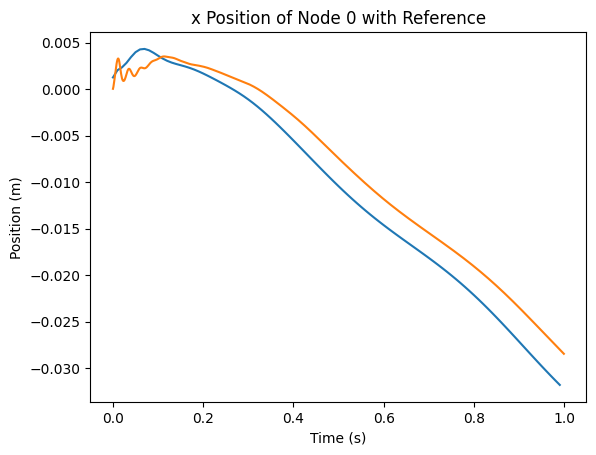

In [13]:
# plot the ref trajectory of node0 on top of qs[:,0]
plt.plot(t[::10], ref_data_node0)
plt.title("x Position of Node 0 with Reference")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.plot(t, qs[:, 0])
plt.show()

In [ ]:
# import json
# import numpy as np

# def save_robot_state_to_json(state, filename="final_state.json"):
#     """
#     Save the entire RobotState object to a JSON file.
#     Automatically converts numpy arrays to lists.
#     """
#     state_dict = {}
    
#     # loop through all attributes of the state
#     for attr in dir(state):
#         # skip private attributes and methods
#         if attr.startswith("_"):
#             continue
#         val = getattr(state, attr)
        
#         # skip callables (methods, properties that are functions)
#         if callable(val):
#             continue
        
#         # convert numpy arrays to lists for JSON serialization
#         if isinstance(val, np.ndarray):
#             state_dict[attr] = val.tolist()
#         else:
#             # handle nested numpy arrays or None/float/int
#             try:
#                 json.dumps(val)  # test if JSON serializable
#                 state_dict[attr] = val
#             except TypeError:
#                 # fallback for unknown types (e.g., other custom objects)
#                 state_dict[attr] = str(val)

#     # write to JSON
#     with open(filename, "w") as f:
#         json.dump(state_dict, f, indent=2)

# # --- usage ---
# final_state = robots[-1].state
# save_robot_state_to_json(final_state, "final_state.json")
# print("Saved full state to final_state.json")
